STEP 2: DATA CLEANING AND PREPROCESSING
Project: Multi-View Mental Health Severity Prediction

Loading datasets from raw folder...
✅ RMHD loaded: (1257, 350)
✅ Depression loaded: (3553, 2)

Cleaning Depression Dataset (Labeled Data)...

🔍 Missing values before cleaning:
text     0
label    0
dtype: int64
✅ Dropped rows with missing values

🧹 Cleaning text...
✅ Removed 0 empty texts
✅ Removed 4 very short texts (<3 words)

🏷️ Standardizing labels...

📈 Depression after cleaning: (3549, 7)
   Class distribution:
label
mild         290
minimum     2583
moderate     394
severe       282
Name: count, dtype: int64

Cleaning RMHD Dataset (Linguistic Features)...

🔍 Missing values before cleaning:
author    0
date      0
post      0
dtype: int64
✅ Dropped 0 rows with missing essential data

🧹 Cleaning post text...
✅ Removed 0 posts that became empty after cleaning

📅 Processing dates...
✅ Successfully parsed 1257 out of 1257 dates
✅ Removed 0 very short posts

📊 Available linguistic features: 

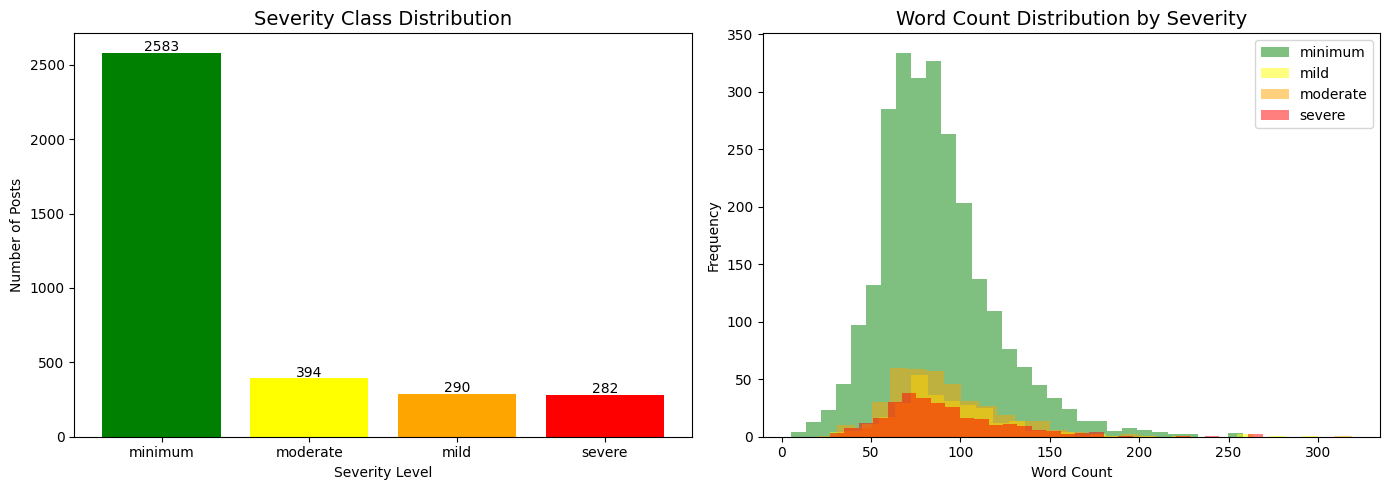

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("STEP 2: DATA CLEANING AND PREPROCESSING")
print("="*70)
print("Project: Multi-View Mental Health Severity Prediction")
print("="*70)

# ===========================================
# LOAD THE RAW DATASETS
# ===========================================

print("\n" + "="*50)
print("Loading datasets from raw folder...")
print("="*50)

rmhd = pd.read_csv('data/raw/rmhd_raw.csv')
depression = pd.read_csv('data/raw/depression_raw.csv')

print(f"✅ RMHD loaded: {rmhd.shape}")
print(f"✅ Depression loaded: {depression.shape}")

# ===========================================
# TEXT CLEANING FUNCTION
# ===========================================

def clean_text(text):
    """
    Clean Reddit posts by removing:
    - URLs
    - Special characters
    - Reddit markup
    - Extra spaces
    - Convert to lowercase
    """
    if pd.isna(text) or text is None:
        return ""

    text = str(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove Reddit markup [deleted], [removed]
    text = re.sub(r'\[(deleted|removed)\]', '', text, flags=re.IGNORECASE)

    # Remove special characters and numbers (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Convert to lowercase
    text = text.lower()

    # Remove extra spaces
    text = ' '.join(text.split())

    return text

# ===========================================
# CLEAN DEPRESSION DATASET (Has Labels)
# ===========================================

print("\n" + "="*50)
print("Cleaning Depression Dataset (Labeled Data)...")
print("="*50)

depression_clean = depression.copy()

# 1. Check missing values
print("\n🔍 Missing values before cleaning:")
print(depression_clean.isnull().sum())

# Drop missing
depression_clean = depression_clean.dropna()
print(f"✅ Dropped rows with missing values")

# 2. Clean text
print("\n🧹 Cleaning text...")
depression_clean['clean_text'] = depression_clean['text'].apply(clean_text)

# 3. Remove empty texts
empty_texts = depression_clean[depression_clean['clean_text'] == ''].shape[0]
depression_clean = depression_clean[depression_clean['clean_text'] != '']
print(f"✅ Removed {empty_texts} empty texts")

# 4. Add basic text features
depression_clean['word_count'] = depression_clean['clean_text'].apply(lambda x: len(x.split()))
depression_clean['char_count'] = depression_clean['clean_text'].apply(len)
depression_clean['sentence_count'] = depression_clean['clean_text'].apply(lambda x: len(re.findall(r'[.!?]+', x)) + 1)

# 5. Remove very short texts (less than 3 words)
short_texts = depression_clean[depression_clean['word_count'] < 3].shape[0]
depression_clean = depression_clean[depression_clean['word_count'] >= 3]
print(f"✅ Removed {short_texts} very short texts (<3 words)")

# 6. Standardize labels
print("\n🏷️ Standardizing labels...")
label_mapping = {
    'minimum': 0,
    'mild': 1,
    'moderate': 2,
    'severe': 3
}
depression_clean['label_encoded'] = depression_clean['label'].map(label_mapping)

# Check for any unmapped labels
if depression_clean['label_encoded'].isna().sum() > 0:
    print(f"⚠️ Found {depression_clean['label_encoded'].isna().sum()} unmapped labels")
    depression_clean = depression_clean.dropna(subset=['label_encoded'])

print(f"\n📈 Depression after cleaning: {depression_clean.shape}")
print(f"   Class distribution:")
print(depression_clean['label'].value_counts().sort_index())

# ===========================================
# CLEAN RMHD DATASET (Has Linguistic Features)
# ===========================================

print("\n" + "="*50)
print("Cleaning RMHD Dataset (Linguistic Features)...")
print("="*50)

rmhd_clean = rmhd.copy()

# 1. Check missing values
print("\n🔍 Missing values before cleaning:")
print(rmhd_clean[['author', 'date', 'post']].isnull().sum())

# Drop rows with missing essential data
initial_rows = len(rmhd_clean)
rmhd_clean = rmhd_clean.dropna(subset=['author', 'post'])
print(f"✅ Dropped {initial_rows - len(rmhd_clean)} rows with missing essential data")

# 2. Clean the post text
print("\n🧹 Cleaning post text...")
rmhd_clean['clean_post'] = rmhd_clean['post'].apply(clean_text)

# 3. Remove empty posts after cleaning
empty_posts = rmhd_clean[rmhd_clean['clean_post'] == ''].shape[0]
rmhd_clean = rmhd_clean[rmhd_clean['clean_post'] != '']
print(f"✅ Removed {empty_posts} posts that became empty after cleaning")

# 4. Parse dates (for metadata, not for temporal modeling)
print("\n📅 Processing dates...")
rmhd_clean['date'] = pd.to_datetime(rmhd_clean['date'], format='%Y/%m/%d', errors='coerce')
valid_dates = rmhd_clean['date'].notna().sum()
print(f"✅ Successfully parsed {valid_dates} out of {len(rmhd_clean)} dates")
rmhd_clean = rmhd_clean.dropna(subset=['date'])

# 5. Add basic text features
rmhd_clean['word_count'] = rmhd_clean['clean_post'].apply(lambda x: len(x.split()))
rmhd_clean['char_count'] = rmhd_clean['clean_post'].apply(len)

# 6. Remove very short posts
short_posts = rmhd_clean[rmhd_clean['word_count'] < 3].shape[0]
rmhd_clean = rmhd_clean[rmhd_clean['word_count'] >= 3]
print(f"✅ Removed {short_posts} very short posts")

# 7. Identify linguistic feature columns
linguistic_features = [
    'automated_readability_index', 'coleman_liau_index',
    'flesch_kincaid_grade_level', 'flesch_reading_ease',
    'gulpease_index', 'gunning_fog_index', 'lix', 'smog_index',
    'wiener_sachtextformel', 'n_chars', 'n_long_words',
    'n_monosyllable_words', 'n_polysyllable_words', 'n_sents',
    'n_syllables', 'n_unique_words'
]

# Check which linguistic features are actually in the dataset
available_ling_features = [f for f in linguistic_features if f in rmhd_clean.columns]
print(f"\n📊 Available linguistic features: {len(available_ling_features)}")
print(f"   Sample: {available_ling_features[:5]}")

# 8. Identify TF-IDF feature columns
tfidf_features = [col for col in rmhd_clean.columns if col.startswith('tfidf_')]
print(f"\n📊 TF-IDF features: {len(tfidf_features)}")

print(f"\n📈 RMHD after cleaning: {rmhd_clean.shape}")

# ===========================================
# SAVE CLEANED DATASETS
# ===========================================

print("\n" + "="*50)
print("Saving cleaned datasets...")
print("="*50)

# Save Depression cleaned
depression_clean.to_csv('data/processed/depression_cleaned.csv', index=False)
print(f"✅ Saved: data/processed/depression_cleaned.csv ({depression_clean.shape})")

# Save RMHD cleaned
rmhd_clean.to_csv('data/processed/rmhd_cleaned.csv', index=False)
print(f"✅ Saved: data/processed/rmhd_cleaned.csv ({rmhd_clean.shape})")

# ===========================================
# CREATE CLEANING SUMMARY
# ===========================================

print("\n" + "="*50)
print("📊 CLEANING SUMMARY")
print("="*50)

print(f"""
DEPRESSION DATASET (For Training):
   Original rows    : {len(depression)}
   Final rows       : {len(depression_clean)}
   Removed          : {len(depression) - len(depression_clean)} rows
   Classes          : {depression_clean['label'].unique().tolist()}
   Class distribution:
      minimum  : {len(depression_clean[depression_clean['label']=='minimum'])}
      mild     : {len(depression_clean[depression_clean['label']=='mild'])}
      moderate : {len(depression_clean[depression_clean['label']=='moderate'])}
      severe   : {len(depression_clean[depression_clean['label']=='severe'])}
   Avg words/post  : {depression_clean['word_count'].mean():.1f}

RMHD DATASET (For Features):
   Original rows    : {len(rmhd)}
   Final rows       : {len(rmhd_clean)}
   Removed          : {len(rmhd) - len(rmhd_clean)} rows
   Linguistic features : {len(available_ling_features)}
   TF-IDF features     : {len(tfidf_features)}
   Avg words/post      : {rmhd_clean['word_count'].mean():.1f}
""")

# ===========================================
# VISUALIZE CLASS DISTRIBUTION
# ===========================================

print("\n" + "="*50)
print("Creating initial visualizations...")
print("="*50)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Class distribution in Depression dataset
class_counts = depression_clean['label'].value_counts()
colors = ['green', 'yellow', 'orange', 'red']
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors)
axes[0].set_title('Severity Class Distribution', fontsize=14)
axes[0].set_xlabel('Severity Level')
axes[0].set_ylabel('Number of Posts')
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(count), ha='center', fontsize=10)

# Plot 2: Word count distribution by class
for i, label in enumerate(['minimum', 'mild', 'moderate', 'severe']):
    class_data = depression_clean[depression_clean['label'] == label]['word_count']
    axes[1].hist(class_data, alpha=0.5, label=label, bins=30, color=colors[i])
axes[1].set_title('Word Count Distribution by Severity', fontsize=14)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_plots/initial_eda.png', dpi=300, bbox_inches='tight')
print("✅ Saved: eda_plots/initial_eda.png")

# ===========================================
# SAVE CLEANING LOG
# ===========================================

with open('logs/data_cleaning.log', 'w') as f:
    f.write("="*70 + "\n")
    f.write("DATA CLEANING LOG\n")
    f.write(f"Date: {pd.Timestamp.now()}\n")
    f.write("="*70 + "\n\n")

    f.write("DEPRESSION DATASET:\n")
    f.write(f"  Original: {depression.shape}\n")
    f.write(f"  Final: {depression_clean.shape}\n")
    f.write(f"  Class distribution:\n")
    for label, count in depression_clean['label'].value_counts().items():
        f.write(f"    {label}: {count}\n")

    f.write("\nRMHD DATASET:\n")
    f.write(f"  Original: {rmhd.shape}\n")
    f.write(f"  Final: {rmhd_clean.shape}\n")
    f.write(f"  Linguistic features: {len(available_ling_features)}\n")
    f.write(f"  TF-IDF features: {len(tfidf_features)}\n")

print("\n" + "="*70)
print("✅ STEP 2 COMPLETE!")
print("="*70)
print("\n📁 Next steps:")
print("   1. Run EDA script to explore data in depth")
print("   2. Extract features for multi-view analysis")
print("   3. Train baseline models")
print("\n📊 Files created:")
print("   - data/processed/depression_cleaned.csv")
print("   - data/processed/rmhd_cleaned.csv")
print("   - eda_plots/initial_eda.png")
print("   - logs/data_cleaning.log")